# ATM 407: meet your atmospheric column

A climate model does not know any meteorology. It knows how to move energy and
water between a stack of boxes, and every rule for doing that has to be written
down by somebody. Those rules are called **parameterizations**, and this
notebook introduces them one at a time.

The column you are about to meet has twenty layers, sits over an ocean, and is
lit by the sun. In each section below you will switch on a single
parameterization, look at what it does to the column on its own, and then turn a
knob and watch the answer move.

Nothing here runs the model forward in time. Every figure is a snapshot of a
single physics step, so what you see is the *rule*. Putting
the rules together and letting them run is the second notebook,
`02_experiments.ipynb`.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/evanwellmeyer/GCM/blob/main/notebooks/01_meet_the_column.ipynb)


## Setup

Run these three cells once, in order.


In [30]:
#@title Install and connect the SCM { display-mode: "form" }
from pathlib import Path
import json
import subprocess
import sys

incolab = 'google.colab' in sys.modules
if incolab:
    root = Path('/content/GCM')
    if not root.exists():
        subprocess.run([
            'git', 'clone', '--depth', '1',
            'https://github.com/evanwellmeyer/GCM.git', str(root),
        ], check=True)
else:
    root = Path.cwd().resolve()
    while root != root.parent and not (root / 'pyproject.toml').exists():
        root = root.parent

if not (root / 'pyproject.toml').exists():
    raise FileNotFoundError('Open this notebook from inside the GCM repository.')
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from importlib import metadata, util

try:
    metadata.version('gcm-scm')
    installed = util.find_spec('matplotlib') is not None
except metadata.PackageNotFoundError:
    installed = False

if not installed:
    subprocess.run([
        sys.executable, '-m', 'pip', 'install', '--quiet', '-e', f'{root}[plot]',
    ], check=True)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import scm
print('SCM ready')

SCM ready


In [31]:
#@title Imports and visual style { display-mode: "form" }
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import torch

import scm.column_model as columnmodel
from scm.column_model import initial_state, physics_step, run, surface_fluxes, update_derived
from scm.boundary_layer import boundary_layer_mixing
from scm.condensation import condensation
from scm.configuration import extract_param_overrides, load_run_config
from scm.convection_mf import dilute_cape, mass_flux_convection, parcel_ascent
from scm.dry_adjustment import dry_adjustment
from scm.ensemble import default_params
from scm.thermo import (
    Lv, Rd, cp, g, kappa, make_grid, p0, relative_humidity,
    saturation_specific_humidity,
)
from scm.radiation_schemes.multiband import (
    compute_longwave_multiband, compute_shortwave_multiband,
)

torch.manual_seed(0)
device = torch.device('cpu')
plt.rcParams.update({
    'figure.facecolor': '#f7f3ea',
    'axes.facecolor': '#fffdf7',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'font.size': 11,
})
colors = {
    'sky': '#3a86ff', 'storm': '#264653', 'rain': '#00a896',
    'heat': '#ef476f', 'sun': '#ffb703', 'cloud': '#8d99ae',
}
print('device:', device)


device: cpu


In [32]:
#@title Load the column { display-mode: "form" }
experiment = {
    'nlevels': 20,
    'dt': 900.0,
    'surface_temperature': 290.0,
    'surface_pressure': 100000.0,
    'solar_constant': 1360.0,
    'zenith_factor': 0.25,
    'ocean_depth': 50.0,
    'surface_albedo': 0.32,
    'wind_speed': 5.0,
}

def makeparams(updates=None):
    """Every parameter the model needs, read from scm/configs/atm407.toml."""
    params = default_params(device=device)
    params.update(extract_param_overrides(load_run_config(root / 'scm/configs/atm407.toml')))
    params.update({
        'dt': experiment['dt'],
        'ps0': experiment['surface_pressure'],
        'ts_init': experiment['surface_temperature'],
        'solar_constant': experiment['solar_constant'],
        'zenith_factor': experiment['zenith_factor'],
        'ocean_depth': experiment['ocean_depth'],
        'albedo': experiment['surface_albedo'],
        'wind_speed': experiment['wind_speed'],
        'use_slab_ocean': True,
        'profile_diagnostics': True,
    })
    if updates is not None:
        params.update(updates)
    return params

def column(updates=None):
    """Grid, parameters and a fresh copy of the saved equilibrium column."""
    grid = make_grid(experiment['nlevels'], device=device)
    params = makeparams(updates)
    state = initial_state(1, grid, params, device=device)
    reference = np.load(root / 'notebooks/data/atm407_equilibrium_20level.npz')
    for name in ('t', 'q', 'qc', 'cloud_fraction'):
        state[name][0] = torch.as_tensor(reference[name], dtype=state[name].dtype)
    state['ts'].fill_(float(reference['ts']))
    state['ps'].fill_(float(reference['ps']))
    state['slab_ts_ref'] = state['ts'].clone()
    state['slab_energy'].zero_()
    return grid, params, update_derived(state, grid)

def pressure_hpa(state):
    return state['p'][0].cpu().numpy() / 100

def half_pressure_hpa(grid, state):
    return grid['sigma_half'].cpu().numpy() * state['ps'][0].item() / 100

def profile(tensor, scale=1.0):
    return tensor[0].detach().cpu().numpy() * scale

def pressure_axis(ax, label='pressure (hPa)'):
    ax.invert_yaxis()
    ax.set_ylabel(label)
    ax.grid(alpha=0.2)

grid, params, state = column()
metadata = json.loads((root / 'notebooks/data/atm407_equilibrium_20level.json').read_text())
print('configuration:', metadata['configuration_label'])
print(f"surface temperature: {metadata['surface_temperature_k']:.2f} K")
print(f"top-of-atmosphere imbalance: {metadata['toa_net_wm2']:+.2f} W m-2")
print(f"{experiment['nlevels']} layers, from {pressure_hpa(state)[0]:.0f} hPa "
      f"down to {pressure_hpa(state)[-1]:.0f} hPa")


configuration: atm407_flux_v1
surface temperature: 287.41 K
top-of-atmosphere imbalance: +0.93 W m-2
20 layers, from 10 hPa down to 998 hPa


## 1. The grid: where are the layers?

Before any physics, a decision: where do you cut the atmosphere into boxes?

This model uses a **sigma coordinate**. Sigma is pressure divided by surface
pressure, so sigma runs from 0 at the top of the atmosphere to 1 at the ground,
and a layer's thickness in sigma is a fixed fraction of the column's mass. That
is the useful property: *pressure is mass*. A layer spanning 50 hPa contains the
same amount of air wherever it sits.

Look at the two thickness panels below and notice that they disagree about where
the grid is fine. In pressure the layers are thickest in the middle of the
column; in height they get monotonically thicker going up. Both are true, and
the reason is that air is compressible - the same 50 hPa of mass occupies far
more vertical distance at 300 hPa than at 900 hPa. Models are built to resolve
the surface well because that is where the sharp gradients are, and this grid
does: the bottom layer is about 40 m deep, the top one several kilometres.

**Read the figure and record:** The bottom layer is about 40 m deep and the top
one several kilometres, yet both hold a similar share of the column's mass.

> **What you observed:** Layer thickness in pressure is largest at ______ hPa; in
> height it is largest at ______ km. One sentence on why the two panels disagree:
> ______


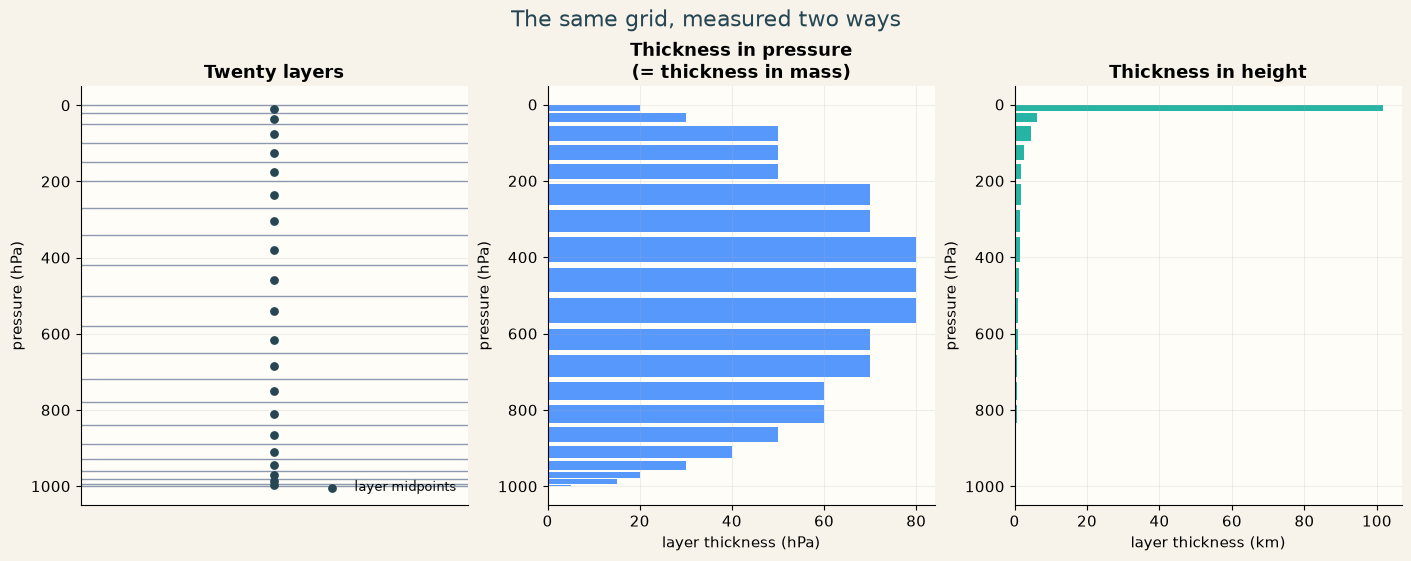

thinnest layer: 5.0 hPa  =  41 m (at the surface)
thickest layer: 80.0 hPa  =  1.4 km
top layer:      20.0 hPa  =  101.8 km

Try: which panel would you use to argue the grid is well designed?


In [33]:
#@title The vertical grid { display-mode: "form" }
grid, params, state = column()
pressure = pressure_hpa(state)
half = half_pressure_hpa(grid, state)
layer_dp = profile(state['dp']) / 100
# hydrostatic layer thickness: dz = R T / g * d(ln p)
mean_t = profile(state['t'])
layer_dz = Rd * mean_t / g * np.log(half[1:] / np.maximum(half[:-1], 1e-6))

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), constrained_layout=True)

axes[0].hlines(half, 0, 1, color=colors['cloud'], linewidth=1)
axes[0].scatter(np.full_like(pressure, 0.5), pressure, s=28,
                color=colors['storm'], zorder=3, label='layer midpoints')
axes[0].set(xlim=(0, 1), xticks=[], title='Twenty layers')
axes[0].legend(frameon=False, fontsize=9, loc='lower right')
pressure_axis(axes[0])

axes[1].barh(pressure, layer_dp, height=layer_dp * 0.8,
             color=colors['sky'], alpha=0.85)
axes[1].set(xlabel='layer thickness (hPa)', title='Thickness in pressure\n(= thickness in mass)')
pressure_axis(axes[1])

axes[2].barh(pressure, layer_dz / 1000, height=layer_dp * 0.8,
             color=colors['rain'], alpha=0.85)
axes[2].set(xlabel='layer thickness (km)', title='Thickness in height')
pressure_axis(axes[2])

fig.suptitle('The same grid, measured two ways', fontsize=16, color=colors['storm'])
plt.show()

print(f'thinnest layer: {layer_dp.min():.1f} hPa  =  {layer_dz.min():.0f} m (at the surface)')
print(f'thickest layer: {layer_dp.max():.1f} hPa  =  {layer_dz[layer_dp.argmax()]/1000:.1f} km')
print(f'top layer:      {layer_dp[0]:.1f} hPa  =  {layer_dz[0]/1000:.1f} km')
print()
print('Try: which panel would you use to argue the grid is well designed?')


## 2. Longwave radiation: the column's only way to lose energy

Everything the Earth absorbs from the sun has to leave again as infrared. That
is the whole job of the longwave scheme, and it is the one part of the model
that connects the column to space.

The scheme works in **four bands**. Band 0 is the atmospheric window - the
wavelengths where clean air is nearly transparent, so radiation from the surface
escapes straight to space. The other three bands have progressively stronger
water-vapour absorption. Each layer is given an optical depth

$$\tau = \kappa_{\rm wv} q \frac{\Delta p}{g} + \tau_{\rm CO_2}(\text{layer mass fraction}) + \tau_{\rm trace},$$

and its transmissivity is $\exp(-\tau)$. Radiation is then swept downward from the
top and upward from the surface, each layer absorbing what arrives and emitting
$\sigma T^4$ of its own. The temperature tendency is what is left over.

Two things are worth watching in the figure. First, **where the optical depth
is**: almost all of it is in the lowest few kilometres, because that is where
the water vapour is. Second, **the emission level**: the outgoing radiation does
not come from the ground, it comes from roughly wherever the optical depth
counting down from space reaches one. Raise CO2 and that level moves up into
colder air, the column emits less, and the planet has to warm to get back to
balance. That is the greenhouse effect, and you can watch it in one number
below.

**Turn the knob and record:** Move `co2_ppm` across its full range, from 200 to
1600, and watch the emission level and the outgoing longwave number.

> **What you observed:** At 200 ppm the OLR is ______ W/m2; at 1600 ppm it is
> ______ W/m2. The emission level moved ______ (up/down), which means it now sits
> in ______ (warmer/colder) air. Where in the column did the optical depth change
> most, and why there? ______


In [ ]:
#@title slide for CO2 concentration { display-mode: "form" }
co2_ppm = 400 #@param {type:"slider", min:200, max:1600, step:50}

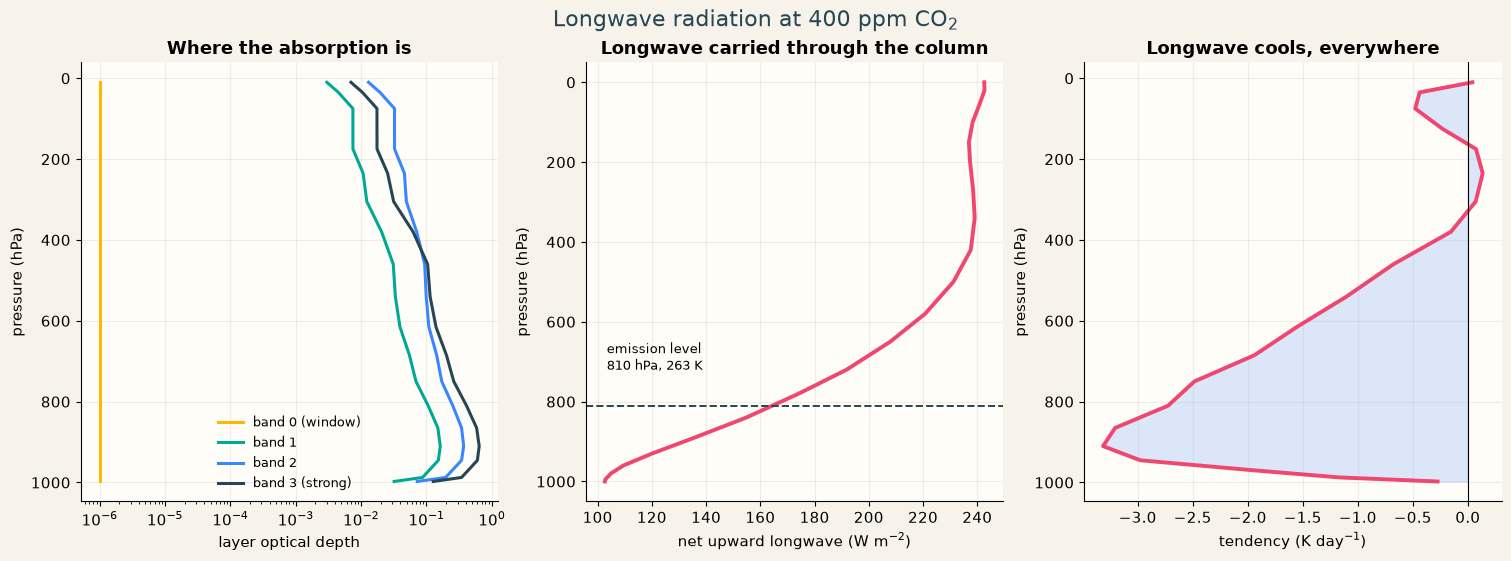

outgoing longwave at the top:   242.56 W m-2
longwave down at the surface:   284.31 W m-2
surface emission (sigma T^4):   387.00 W m-2
trapped by the atmosphere:      144.44 W m-2   <- the greenhouse effect

Try: move CO2 from 400 to 800 and watch the outgoing longwave fall. That
drop is the forcing the planet then has to warm up to undo.


In [35]:
#@title What longwave radiation does { display-mode: "form" }
grid, params, state = column({'co2': float(co2_ppm)})
pressure = pressure_hpa(state)
half = half_pressure_hpa(grid, state)

lw_heating, lw_down_surface, olr = compute_longwave_multiband(state, grid, params)

# Rebuild the per-band optical depth the scheme uses, so the bands are visible.
band_kappa = np.asarray(params['lw_band_wv_kappa'], dtype=float)
band_co2 = np.asarray(params['lw_band_co2_base_tau'], dtype=float)
band_co2_log = np.asarray(params['lw_band_co2_log_factor'], dtype=float)
band_weights = np.asarray(params['lw_band_weights'], dtype=float)
q = profile(state['q'])
dp = profile(state['dp'])
mass_fraction = dp / dp.sum()
co2_ratio = float(co2_ppm) / float(params['co2_ref'])
band_tau = np.array([
    band_kappa[b] * q * dp / g
    + (band_co2[b] + band_co2_log[b] * np.log(max(co2_ratio, 0.01))) * mass_fraction
    for b in range(len(band_weights))
])

# net upward longwave flux, recovered from the heating profile
lw_net_flux = olr[0].item() + np.concatenate(
    [[0.0], np.cumsum(cp / g * profile(lw_heating) * dp)])

# emission level: where optical depth counting down from space reaches one
column_tau = (band_tau * band_weights[:, None]).sum(axis=0)
cumulative_tau = np.cumsum(column_tau)
emission_index = int(np.argmin(np.abs(cumulative_tau - 1.0)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), constrained_layout=True)

band_labels = ['band 0 (window)', 'band 1', 'band 2', 'band 3 (strong)']
band_colors = [colors['sun'], colors['rain'], colors['sky'], colors['storm']]
for b in range(len(band_weights)):
    axes[0].plot(np.maximum(band_tau[b], 1e-6), pressure, linewidth=2.2,
                 color=band_colors[b], label=band_labels[b])
axes[0].set(xscale='log', xlabel='layer optical depth', title='Where the absorption is')
axes[0].legend(frameon=False, fontsize=9)
pressure_axis(axes[0])

axes[1].plot(lw_net_flux, half, color=colors['heat'], linewidth=2.8)
axes[1].axhline(pressure[emission_index], color=colors['storm'],
                linestyle='--', linewidth=1.4)
axes[1].annotate(f'emission level\n{pressure[emission_index]:.0f} hPa, '
                 f'{profile(state["t"])[emission_index]:.0f} K',
                 xy=(0.05, 0.30), xycoords='axes fraction', fontsize=9)
axes[1].set(xlabel='net upward longwave (W m$^{-2}$)',
            title='Longwave carried through the column')
pressure_axis(axes[1])

heating = profile(lw_heating, 86400)
axes[2].plot(heating, pressure, color=colors['heat'], linewidth=2.8)
axes[2].fill_betweenx(pressure, 0, heating, color=colors['sky'], alpha=0.18)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set(xlabel='tendency (K day$^{-1}$)', title='Longwave cools, everywhere')
pressure_axis(axes[2])

fig.suptitle(f'Longwave radiation at {co2_ppm} ppm CO$_2$', fontsize=16, color=colors['storm'])
plt.show()

print(f'outgoing longwave at the top:  {olr[0].item():7.2f} W m-2')
print(f'longwave down at the surface:  {lw_down_surface[0].item():7.2f} W m-2')
print(f'surface emission (sigma T^4):  {5.670374e-8 * state["ts"][0].item()**4:7.2f} W m-2')
print(f'trapped by the atmosphere:     '
      f'{5.670374e-8 * state["ts"][0].item()**4 - olr[0].item():7.2f} W m-2   <- the greenhouse effect')
print()
print('Try: move CO2 from 400 to 800 and watch the outgoing longwave fall. That')
print('drop is the forcing the planet then has to warm up to undo.')


## 3. Shortwave radiation: where the sunlight goes

Sunlight is easier. There is one source, it comes from one direction, and the
atmosphere is mostly transparent to it. The scheme uses three bands, gives water
vapour a weak absorption in the middle one and ozone a little in the top, passes
the beam down through the column, reflects a fraction `albedo` off the surface,
and passes it back up.

The insolation is the solar constant times a **zenith factor** of 0.25. That
factor is doing a lot of quiet work: it converts the beam hitting a disc into an
average over a rotating sphere. It is why the column sees about 340 W/m2 rather
than 1360.

Notice how little of the sunlight the atmosphere absorbs compared with how much
longwave it traps. The atmosphere is nearly transparent to sunlight and nearly
opaque to infrared, and that asymmetry *is* the greenhouse effect.

**Turn the knob and record:** Move `surface_albedo` from 0.05 to 0.60 and watch
both the absorbed sunlight and the shape of the shortwave heating profile.

> **What you observed:** Absorbed solar radiation goes from ______ W/m2 to ______
> W/m2. Did the *shape* of the atmospheric heating profile change as much as its
> magnitude? ______ Compare the atmosphere's shortwave absorption with the
> longwave trapping you measured in section 2: ______


In [ ]:
#@title slider for surface albedo { display-mode: "form" }
surface_albedo = 0.32 #@param {type:"slider", min:0.05, max:0.60, step:0.01}

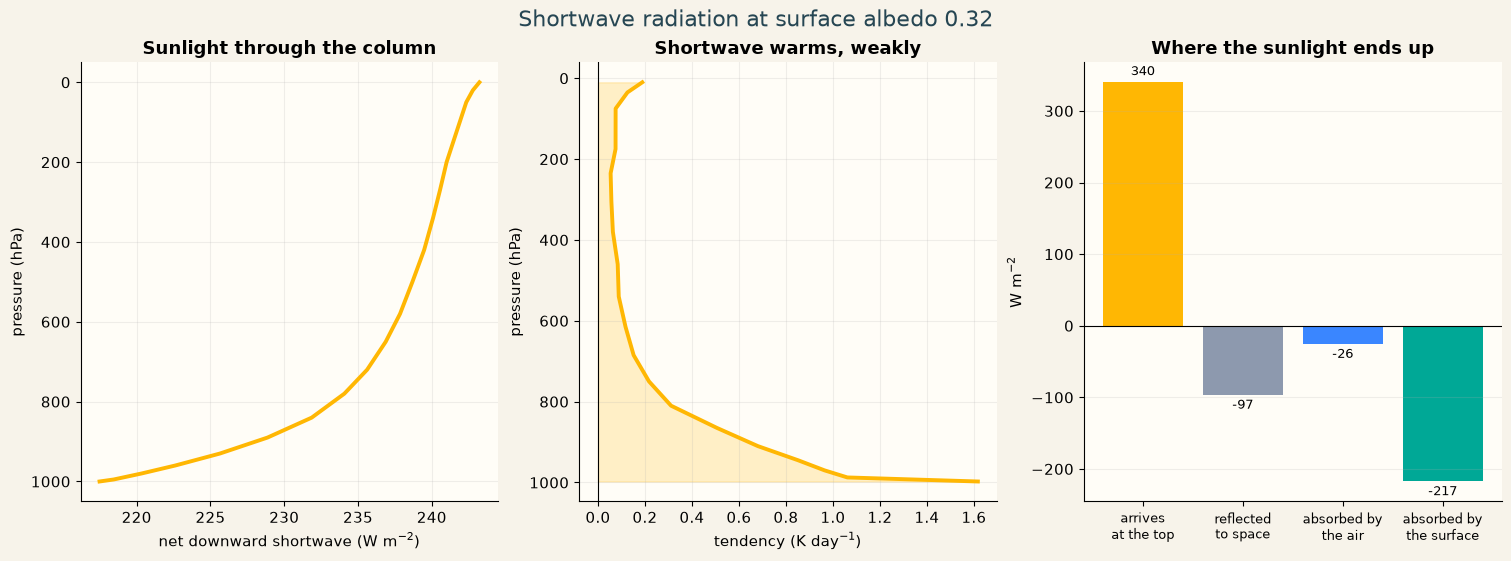

insolation at the top:         340.00 W m-2   (= 1360 x 0.25)
absorbed solar (ASR):          243.23 W m-2
reflected to space:             96.77 W m-2
planetary albedo:               0.285
absorbed by the atmosphere:     25.75 W m-2
absorbed by the surface:       217.48 W m-2

Try: the planetary albedo is not the same as the surface albedo you set.
Why is it different, and which way does the difference go?


In [37]:
#@title What shortwave radiation does { display-mode: "form" }
grid, params, state = column({'albedo': float(surface_albedo)})
pressure = pressure_hpa(state)
half = half_pressure_hpa(grid, state)
dp = profile(state['dp'])

sw_heating, sw_surface, asr, sw_reflected, insolation = compute_shortwave_multiband(
    state, grid, params)
sw_net_flux = -asr[0].item() + np.concatenate(
    [[0.0], np.cumsum(cp / g * profile(sw_heating) * dp)])

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), constrained_layout=True)

axes[0].plot(-sw_net_flux, half, color=colors['sun'], linewidth=2.8)
axes[0].set(xlabel='net downward shortwave (W m$^{-2}$)',
            title='Sunlight through the column')
pressure_axis(axes[0])

heating = profile(sw_heating, 86400)
axes[1].plot(heating, pressure, color=colors['sun'], linewidth=2.8)
axes[1].fill_betweenx(pressure, 0, heating, color=colors['sun'], alpha=0.20)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set(xlabel='tendency (K day$^{-1}$)', title='Shortwave warms, weakly')
pressure_axis(axes[1])

atmospheric_absorption = asr[0].item() - sw_surface[0].item()
budget = [insolation[0].item(), -sw_reflected[0].item(),
          -atmospheric_absorption, -sw_surface[0].item()]
labels = ['arrives\nat the top', 'reflected\nto space',
          'absorbed by\nthe air', 'absorbed by\nthe surface']
bars = axes[2].bar(range(4), budget,
                   color=[colors['sun'], colors['cloud'], colors['sky'], colors['rain']])
axes[2].bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_xticks(range(4), labels, fontsize=9)
axes[2].set(ylabel='W m$^{-2}$', title='Where the sunlight ends up')
axes[2].grid(axis='y', alpha=0.2)

fig.suptitle(f'Shortwave radiation at surface albedo {surface_albedo:.2f}',
             fontsize=16, color=colors['storm'])
plt.show()

print(f'insolation at the top:        {insolation[0].item():7.2f} W m-2'
      f'   (= {params["solar_constant"]:.0f} x {params["zenith_factor"]})')
print(f'absorbed solar (ASR):         {asr[0].item():7.2f} W m-2')
print(f'reflected to space:           {sw_reflected[0].item():7.2f} W m-2')
print(f'planetary albedo:             {sw_reflected[0].item() / insolation[0].item():7.3f}')
print(f'absorbed by the atmosphere:   {atmospheric_absorption:7.2f} W m-2')
print(f'absorbed by the surface:      {sw_surface[0].item():7.2f} W m-2')
print()
print('Try: the planetary albedo is not the same as the surface albedo you set.')
print('Why is it different, and which way does the difference go?')


## 4. Radiation on its own would build an impossible atmosphere

Add the two together and a problem appears. Longwave cools the whole troposphere
at 1-2 K/day; shortwave warms it far more weakly. The net is cooling nearly
everywhere, while the surface is being heated hard by absorbed sunlight.

If radiation were the only process, the column would settle into **radiative
equilibrium**: a very hot surface, a sharp temperature drop immediately above it,
and a lapse rate far steeper than the dry adiabat through the lower troposphere.
That state is *statically unstable*. Real air will not sit in it - it overturns.

Everything in the rest of this notebook exists to carry the energy that
radiation dumps at the surface up to the level where it can be radiated away:
turbulence in the boundary layer, then convection above it. The panel on the
right shows the size of the job.

**Read the figure and record:** This is the problem every later section exists to
solve, so put a number on it.

> **What you observed:** Net radiative cooling of the troposphere is about ______
> K/day. The radiative-equilibrium lapse rate is ______ K/km against a dry adiabat
> of 9.8 K/km. In one sentence, what would happen to real air placed in that
> profile? ______


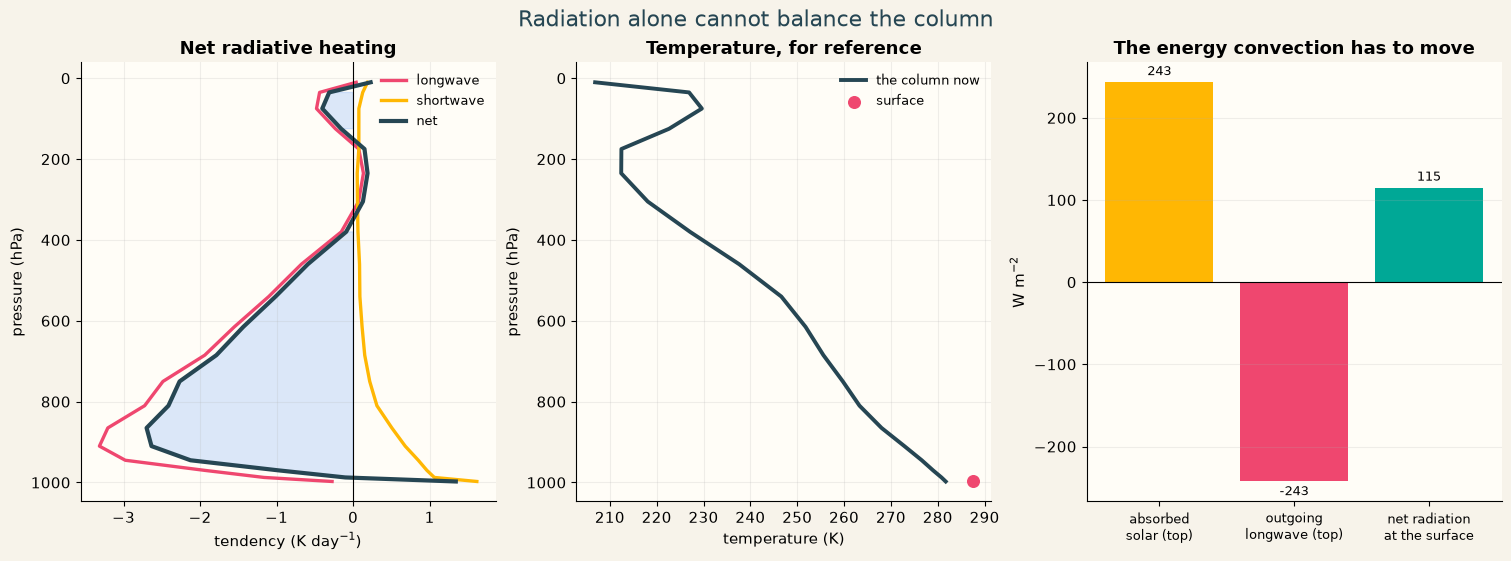

net radiation into the surface: +114.81 W m-2
The surface is gaining this much every second from radiation alone.
Something non-radiative has to carry it upward, or the surface cooks.
That something is sections 5 to 9.


In [38]:
#@title Radiation's problem { display-mode: "form" }
grid, params, state = column()
pressure = pressure_hpa(state)
dp = profile(state['dp'])

lw_heating, lw_down_surface, olr = compute_longwave_multiband(state, grid, params)
sw_heating, sw_surface, asr, sw_reflected, insolation = compute_shortwave_multiband(
    state, grid, params)
net = profile(lw_heating + sw_heating, 86400)

_, diagnostics, _ = physics_step(deepcopy(state), grid, params)
surface_radiative = (sw_surface[0].item() + lw_down_surface[0].item()
                     - diagnostics['lw_up_sfc'][0].item())

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), constrained_layout=True)

axes[0].plot(profile(lw_heating, 86400), pressure, color=colors['heat'],
             linewidth=2.4, label='longwave')
axes[0].plot(profile(sw_heating, 86400), pressure, color=colors['sun'],
             linewidth=2.4, label='shortwave')
axes[0].plot(net, pressure, color=colors['storm'], linewidth=3, label='net')
axes[0].fill_betweenx(pressure, 0, net, where=net < 0, color=colors['sky'], alpha=0.18)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set(xlabel='tendency (K day$^{-1}$)', title='Net radiative heating')
axes[0].legend(frameon=False, fontsize=9)
pressure_axis(axes[0])

axes[1].plot(profile(state['t']), pressure, color=colors['storm'], linewidth=2.8,
             label='the column now')
axes[1].scatter([state['ts'][0].item()], [pressure[-1]], s=70, zorder=4,
                color=colors['heat'], label='surface')
axes[1].set(xlabel='temperature (K)', title='Temperature, for reference')
axes[1].legend(frameon=False, fontsize=9)
pressure_axis(axes[1])

flows = [asr[0].item(), -olr[0].item(), surface_radiative]
bars = axes[2].bar(range(3), flows,
                   color=[colors['sun'], colors['heat'], colors['rain']])
axes[2].bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_xticks(range(3), ['absorbed\nsolar (top)', 'outgoing\nlongwave (top)',
                              'net radiation\nat the surface'], fontsize=9)
axes[2].set(ylabel='W m$^{-2}$', title='The energy convection has to move')
axes[2].grid(axis='y', alpha=0.2)

fig.suptitle('Radiation alone cannot balance the column', fontsize=16, color=colors['storm'])
plt.show()

print(f'net radiation into the surface: {surface_radiative:+7.2f} W m-2')
print('The surface is gaining this much every second from radiation alone.')
print('Something non-radiative has to carry it upward, or the surface cooks.')
print('That something is sections 5 to 9.')


## 5. Surface fluxes: how the ocean talks to the air

The surface and the air above it exchange heat two ways. **Sensible heat** moves
because they are at different temperatures. **Latent heat** moves because the air
is not saturated, so water evaporates and carries `Lv` joules per kilogram with
it. Both are written as bulk formulas:

$$\mathrm{SHF} = \rho c_p C_H U(T_{\rm surface} - T_{\rm air})$$

$$\mathrm{LHF} = \rho L_v C_E U[q_{\rm sat}(T_{\rm surface}) - q_{\rm air}].$$

Everything hard is inside the exchange coefficients `C_H` and `C_E`, which stand
in for turbulent eddies the model cannot see. Note the wind speed multiplying
both: a calm ocean barely communicates with the atmosphere, a windy one
communicates strongly. That is why hurricanes intensify over warm water - the
wind they generate increases the evaporation that feeds them.

In this column the latent flux is several times the sensible flux, which is
typical over the tropical ocean. Most of the energy leaving the sea surface
leaves as water, not as warmth.

**Turn the knob and record:** Move `wind_speed` from 1 to 15 m/s and watch both
fluxes respond.

> **What you observed:** At 1 m/s the latent flux is ______ W/m2 and the sensible
> flux ______ W/m2; at 15 m/s they are ______ and ______. The ratio of latent to
> sensible heat is roughly ______, and it did / did not change much with wind
> speed. Why does that ratio matter for a storm over warm water? ______


In [ ]:
#@title slider for wind speed { display-mode: "form" }
wind_speed = 5.0 #@param {type:"slider", min:1.0, max:15.0, step:0.5}

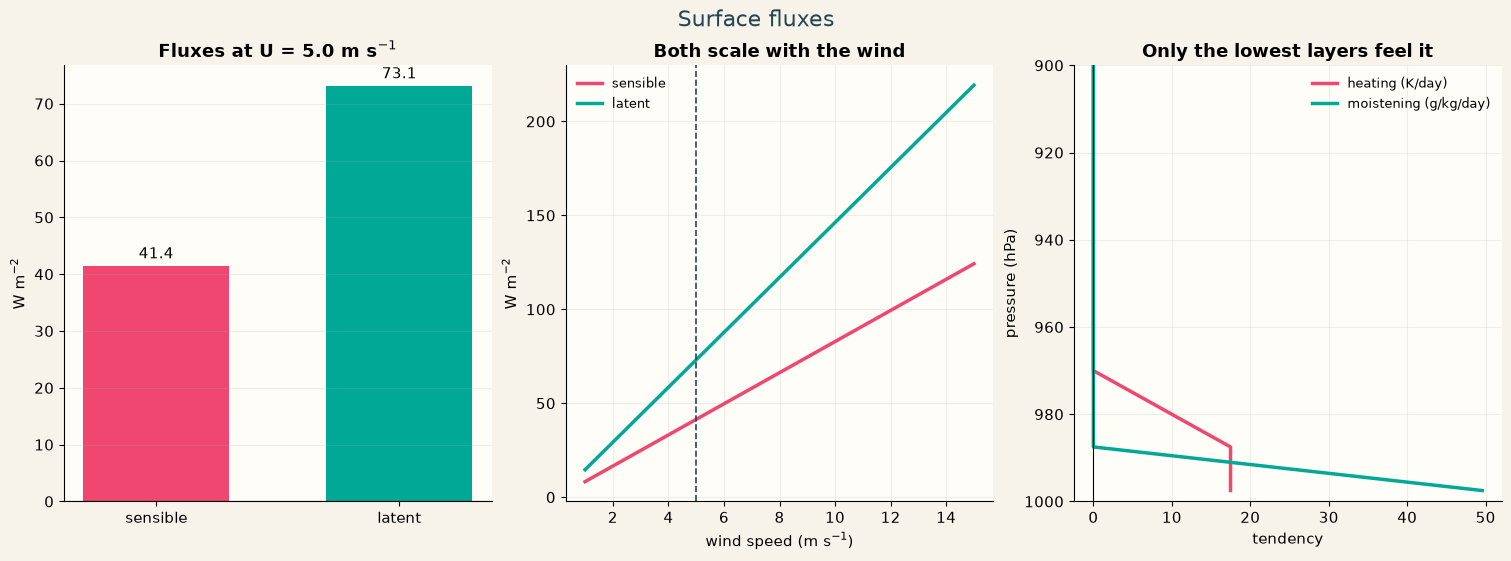

sensible heat flux:   41.41 W m-2
latent heat flux:     73.09 W m-2
Bowen ratio:          0.567   (sensible / latent)
evaporation:           2.53 mm day-1

Try: the surface flux is deposited into only the bottom layer or two.
What would happen if nothing carried it further up?


In [52]:
#@title What the surface fluxes do { display-mode: "form" }
grid, params, state = column({'wind_speed': float(wind_speed)})
pressure = pressure_hpa(state)
flux = surface_fluxes(state, grid, params)

winds = np.linspace(1.0, 15.0, 22)
sensible, latent = [], []
for u in winds:
    g_u, p_u, s_u = column({'wind_speed': float(u)})
    f_u = surface_fluxes(s_u, g_u, p_u)
    sensible.append(f_u['shf'][0].item())
    latent.append(f_u['lhf'][0].item())

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), constrained_layout=True)

values = [flux['shf'][0].item(), flux['lhf'][0].item()]
bars = axes[0].bar(['sensible', 'latent'], values,
                   color=[colors['heat'], colors['rain']], width=0.6)
axes[0].bar_label(bars, fmt='%.1f', padding=3)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set(ylabel='W m$^{-2}$', title=f'Fluxes at U = {wind_speed:.1f} m s$^{{-1}}$')
axes[0].grid(axis='y', alpha=0.2)

axes[1].plot(winds, sensible, color=colors['heat'], linewidth=2.5, label='sensible')
axes[1].plot(winds, latent, color=colors['rain'], linewidth=2.5, label='latent')
axes[1].axvline(wind_speed, color=colors['storm'], linestyle='--', linewidth=1.2)
axes[1].set(xlabel='wind speed (m s$^{-1}$)', ylabel='W m$^{-2}$',
            title='Both scale with the wind')
axes[1].legend(frameon=False, fontsize=9)
axes[1].grid(alpha=0.2)

heat = profile(flux['dt'], 86400)
moisture = profile(flux['dq'], 86400 * 1000)
axes[2].plot(heat, pressure, color=colors['heat'], linewidth=2.5, label='heating (K/day)')
axes[2].plot(moisture, pressure, color=colors['rain'], linewidth=2.5,
             label='moistening (g/kg/day)')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set(xlabel='tendency', title='Only the lowest layers feel it')
axes[2].legend(frameon=False, fontsize=9)
pressure_axis(axes[2])
axes[2].set_ylim(1000, 900)

fig.suptitle('Surface fluxes', fontsize=16, color=colors['storm'])
plt.show()

bowen = flux['shf'][0].item() / max(flux['lhf'][0].item(), 1e-6)
print(f"sensible heat flux: {flux['shf'][0].item():7.2f} W m-2")
print(f"latent heat flux:   {flux['lhf'][0].item():7.2f} W m-2")
print(f"Bowen ratio:        {bowen:7.3f}   (sensible / latent)")
print(f"evaporation:        {flux['lhf'][0].item() / Lv * 86400:7.2f} mm day-1")
print()
print('Try: the surface flux is deposited into only the bottom layer or two.')
print('What would happen if nothing carried it further up?')


## 6. The boundary layer: turbulence you cannot resolve

The bottom kilometre of the atmosphere is stirred by eddies far smaller than a
grid box. The model represents them as **diffusion**: a conductivity `K` that
mixes heat, moisture and momentum between adjacent layers, strong where the air
is turbulent and near zero where it is not.

The scheme has to decide how deep the turbulence goes. It uses a **bulk
Richardson number**, the ratio of stabilising buoyancy to destabilising shear:

$$Ri = \frac{g}{\theta_v}\frac{\partial \theta_v / \partial z}{(\partial u / \partial z)^2}. $$

Below a critical value the layer overturns; above it, stratification wins. The
boundary layer top is the first level where Ri crosses that threshold.

This diagnosis matters more than it sounds. When this model instead cut the
mixing off at a fixed pressure level, the layer just above the cutoff was
coupled to nothing, a statically unstable interface built up there permanently,
and a separate emergency scheme had to run flat out to patch it. Diagnosing the
depth from the flow, which is what every serious model does, made that problem
disappear.

**Turn the knob and record:** Move `wind_speed` and watch the diagnosed boundary
layer top, not just the mixing strength.

> **What you observed:** The boundary layer top sits at ______ hPa at low wind and
> ______ hPa at high wind. The diffusivity K peaks at ______ and falls to near zero
> by ______ hPa. Why does the scheme diagnose this depth from the flow rather than
> fixing it at a set pressure? ______


In [ ]:
#@title slider for wind speed { display-mode: "form" }
wind_speed = 10.0 #@param {type:"slider", min:1.0, max:15.0, step:0.5}

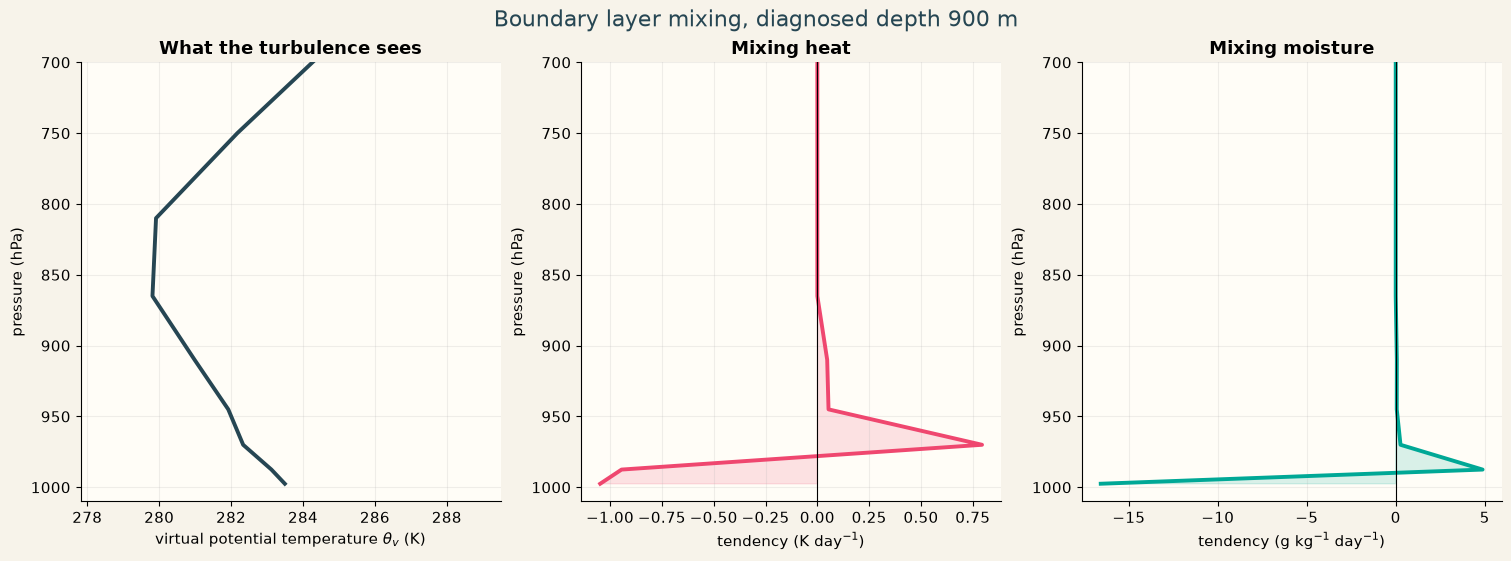

diagnosed boundary layer depth: 900 m
strongest heating:   +0.79 K day-1
strongest cooling:   -1.05 K day-1

Notice the sign flip: the layer touching the ocean is cooled and dried,
the layers above are warmed and moistened. Mixing does not create energy,
it moves it. Try raising the wind speed in section 5 and re-running this.


In [56]:
#@title What the boundary layer does { display-mode: "form" }
grid, params, state = column({'wind_speed': float(wind_speed)})
pressure = pressure_hpa(state)

# surface fluxes first, so the boundary layer has something to mix
warmed = deepcopy(state)
flux = surface_fluxes(warmed, grid, params)
warmed['t'] = warmed['t'] + flux['dt'] * params['dt']
warmed['q'] = warmed['q'] + flux['dq'] * params['dt']
warmed = update_derived(warmed, grid)

mixing = boundary_layer_mixing(warmed, grid, params)
depth = mixing['boundary_layer_depth_m'][0].item()

temperature = profile(warmed['t'])
vapour = profile(warmed['q'])
exner = (profile(warmed['p']) / p0) ** kappa
theta_v = temperature / exner * (1 + 0.608 * vapour)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), constrained_layout=True)

axes[0].plot(theta_v, pressure, color=colors['storm'], linewidth=2.8)
axes[0].set(xlabel=r'virtual potential temperature $\theta_v$ (K)',
            title='What the turbulence sees')
axes[0].set_xlim(theta_v[-8:].min() - 2, theta_v[-8:].max() + 6)
axes[0].set_ylim(1010, 700)
axes[0].grid(alpha=0.2)
axes[0].set_ylabel('pressure (hPa)')

heat = profile(mixing['dt'], 86400)
axes[1].plot(heat, pressure, color=colors['heat'], linewidth=2.8)
axes[1].fill_betweenx(pressure, 0, heat, color=colors['heat'], alpha=0.15)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set(xlabel='tendency (K day$^{-1}$)', title='Mixing heat')
pressure_axis(axes[1])

moisture = profile(mixing['dq'], 86400 * 1000)
axes[2].plot(moisture, pressure, color=colors['rain'], linewidth=2.8)
axes[2].fill_betweenx(pressure, 0, moisture, color=colors['rain'], alpha=0.15)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set(xlabel='tendency (g kg$^{-1}$ day$^{-1}$)', title='Mixing moisture')
pressure_axis(axes[2])

for ax in axes[1:]:
    ax.set_ylim(1010, 700)

fig.suptitle(f'Boundary layer mixing, diagnosed depth {depth:.0f} m',
             fontsize=16, color=colors['storm'])
plt.show()

print(f'diagnosed boundary layer depth: {depth:.0f} m')
print(f'strongest heating:  {heat.max():+6.2f} K day-1')
print(f'strongest cooling:  {heat.min():+6.2f} K day-1')
print()
print('Notice the sign flip: the layer touching the ocean is cooled and dried,')
print('the layers above are warmed and moistened. Mixing does not create energy,')
print('it moves it. Try raising the wind speed in section 5 and re-running this.')


## 7. Dry convective adjustment: the safety net

If a layer ends up colder than the one above it in potential temperature, the
column is upside down. Dense air is sitting on light air, and in reality it would
overturn in minutes. No slow diffusion is going to fix that fast enough.

Dry adjustment is the emergency response. It looks for interfaces where the
lapse rate exceeds the dry adiabat by more than a threshold and mixes them until
they do not. It conserves energy exactly - potential temperature is mixed
weighted by mass times the Exner function, which is what makes uniform mixing
conserve `c_p T` rather than merely `theta`.

The cell below breaks the column on purpose so you can watch the scheme work.
The equilibrium column is stable, so the scheme is silent on it: run the cell
with `heating_kick = 0` and nothing happens at all.

**Turn the knob and record:** Start with `heating_kick = 0` and confirm the scheme
does nothing at all, then raise it and watch the adjustment fire.

> **What you observed:** The scheme stays silent up to a kick of ______ K/day. Once
> it fires, it mixes the layers between ______ and ______ hPa. Compare the
> temperature profile before and after: the adjustment cooled ______ and warmed
> ______. Check the energy: the column-mean temperature changed by ______ K, which
> should be near zero. Now change `lapse_trigger` and say what it controls: ______


In [ ]:
#@title slider for shallow convection heating kick and lapse rate trigger { display-mode: "form" }
heating_kick = 10.0 #@param {type:"slider", min:0.0, max:15.0, step:1.0}
lapse_trigger = 3.0 #@param {type:"slider", min:0.0, max:10.0, step:0.5}

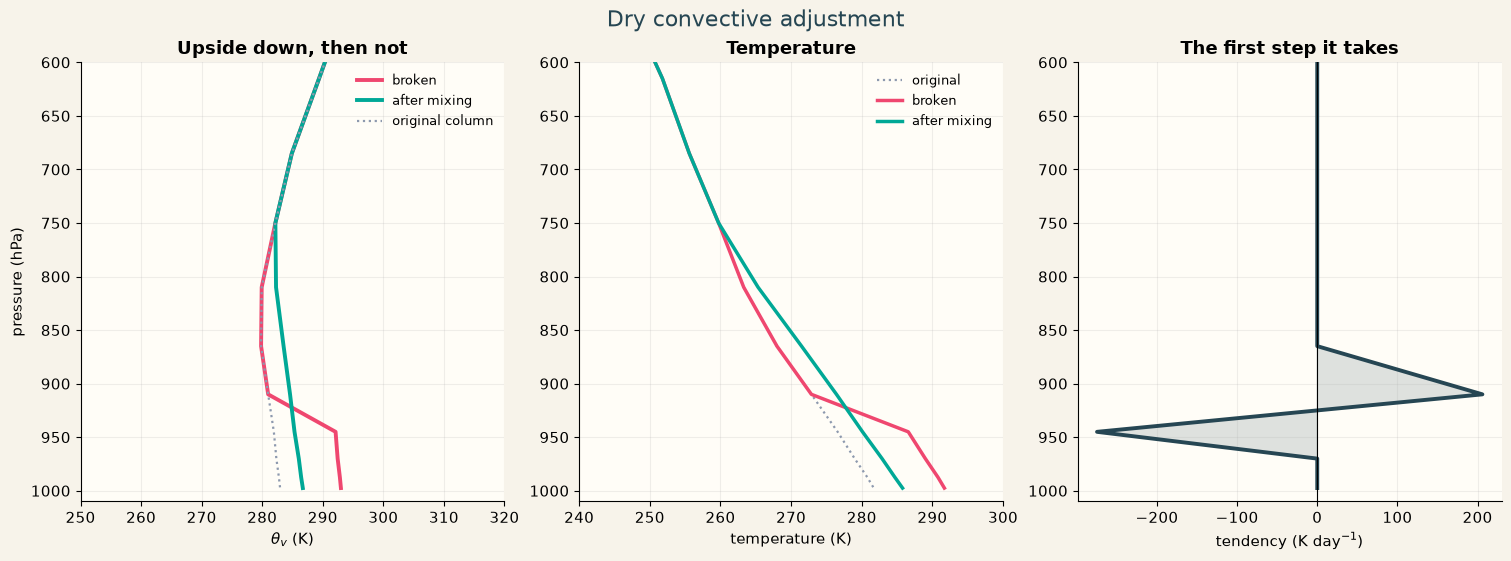

scheme triggered:  yes
column enthalpy before: 2.483224e+09 J m-2
column enthalpy after:  2.483224e+09 J m-2
relative change:        1.03e-07   <- mixing moves energy, it does not make any

Try: set heating_kick to 0. The scheme should do nothing at all, because
the equilibrium column is already stable. Then raise lapse_trigger to 10
and see how much instability the scheme is willing to tolerate.


In [58]:
#@title What dry adjustment does { display-mode: "form" }
grid, params, state = column({'dry_adjustment_max_lapse_excess': float(lapse_trigger)})
pressure = pressure_hpa(state)

broken = deepcopy(state)
broken['t'][:, -4:] = broken['t'][:, -4:] + float(heating_kick)
broken = update_derived(broken, grid)

def virtual_potential(s):
    exner = (profile(s['p']) / p0) ** kappa
    return profile(s['t']) / exner * (1 + 0.608 * profile(s['q']) - profile(s['qc']))

before = virtual_potential(broken)
relaxed = deepcopy(broken)
for _ in range(20):
    out = dry_adjustment(relaxed, grid, params)
    relaxed['t'] = relaxed['t'] + out['dt'] * params['dt']
    relaxed['q'] = relaxed['q'] + out['dq'] * params['dt']
    relaxed['qc'] = relaxed['qc'] + out['dqc'] * params['dt']
after = virtual_potential(relaxed)

first = dry_adjustment(broken, grid, params)
active = first['dry_adjustment_active'][0].item()
mass = profile(broken['dp']) / g
energy_before = float((cp * profile(broken['t']) * mass).sum())
energy_after = float((cp * profile(relaxed['t']) * mass).sum())

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), constrained_layout=True)

axes[0].plot(before, pressure, color=colors['heat'], linewidth=2.8, label='broken')
axes[0].plot(after, pressure, color=colors['rain'], linewidth=2.8, label='after mixing')
axes[0].plot(virtual_potential(state), pressure, color=colors['cloud'],
             linewidth=1.6, linestyle=':', label='original column')
axes[0].set(xlabel=r'$\theta_v$ (K)', title='Upside down, then not')
axes[0].legend(frameon=False, fontsize=9)
axes[0].set_ylim(1010, 600)
axes[0].set_xlim(250, 320)
axes[0].grid(alpha=0.2)
axes[0].set_ylabel('pressure (hPa)')

axes[1].plot(profile(state['t']), pressure, color=colors['cloud'], linewidth=1.6,
             linestyle=':', label='original')
axes[1].plot(profile(broken['t']), pressure, color=colors['heat'], linewidth=2.5,
             label='broken')
axes[1].plot(profile(relaxed['t']), pressure, color=colors['rain'], linewidth=2.5,
             label='after mixing')
axes[1].set(xlabel='temperature (K)', title='Temperature')
axes[1].legend(frameon=False, fontsize=9)
axes[1].set_ylim(1010, 600)
axes[1].set_xlim(240, 300)
axes[1].grid(alpha=0.2)

tendency = profile(first['dt'], 86400)
axes[2].plot(tendency, pressure, color=colors['storm'], linewidth=2.8)
axes[2].fill_betweenx(pressure, 0, tendency, color=colors['storm'], alpha=0.15)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set(xlabel='tendency (K day$^{-1}$)', title='The first step it takes')
axes[2].set_ylim(1010, 600)
axes[2].grid(alpha=0.2)

fig.suptitle('Dry convective adjustment', fontsize=16, color=colors['storm'])
plt.show()

print(f'scheme triggered:  {"yes" if active > 0 else "no"}')
print(f'column enthalpy before: {energy_before:.6e} J m-2')
print(f'column enthalpy after:  {energy_after:.6e} J m-2')
print(f'relative change:        {abs(energy_after - energy_before) / energy_before:.2e}'
      f'   <- mixing moves energy, it does not make any')
print()
print('Try: set heating_kick to 0. The scheme should do nothing at all, because')
print('the equilibrium column is already stable. Then raise lapse_trigger to 10')
print('and see how much instability the scheme is willing to tolerate.')


## 8. Shallow convection: the cumulus that never rain

Between the turbulent boundary layer and deep raining towers sits a third
regime: fields of small cumulus, a kilometre or two tall, that ventilate the
subcloud layer without producing much rain. They are how the trade-wind
atmosphere transports moisture upward most of the time.

The scheme here is deliberately simple. It moves heat and moisture between a
base level and a top level on a fixed timescale when the subcloud air is humid
enough to trigger it, and it is suppressed when deep convection is already
active. It has no plume, no entrainment, no cloud - it is a transport rule.

**Read the figure and record:** This scheme has no plume and no cloud, so its
fingerprint should look different from deep convection in the next section.

> **What you observed:** Shallow convection moves moisture from ______ hPa to
> ______ hPa. Its temperature tendency is ______ K/day at most, compared with the
> deep scheme's ______ K/day once you reach section 9. Does it produce any rain?
> ______


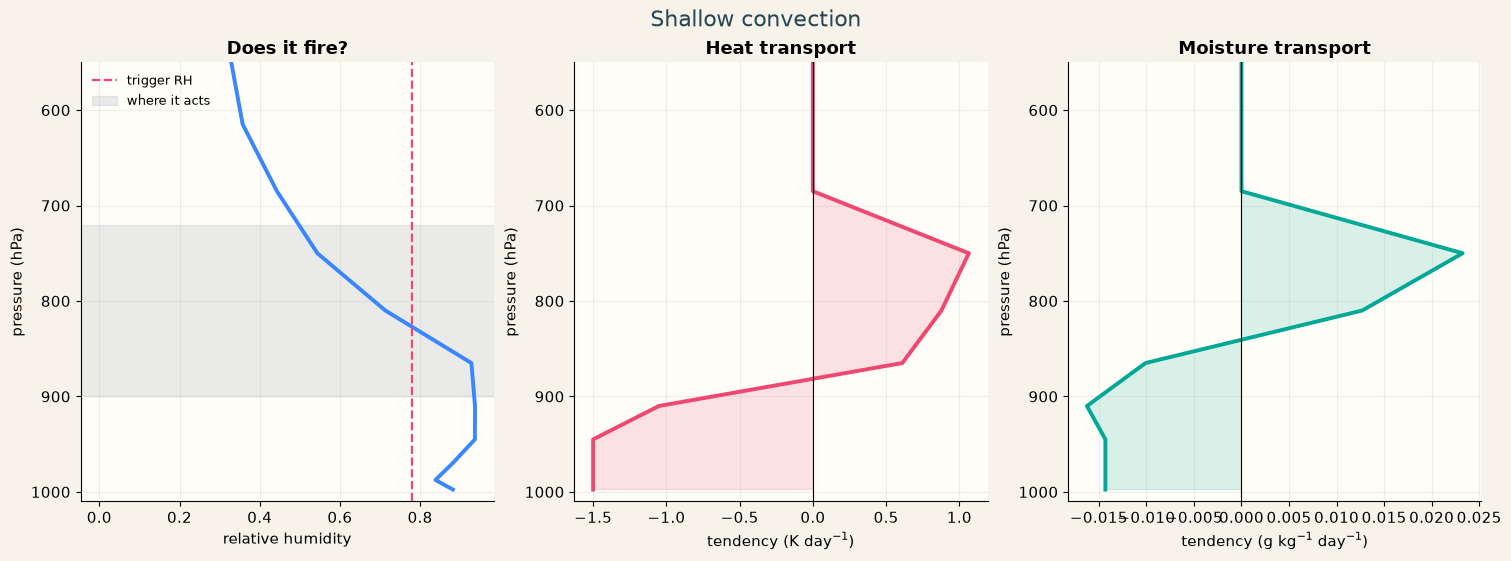

shallow rain: 0.0000 mm day-1   <- close to zero, by design
peak drying:   -0.02 g kg-1 day-1
peak moistening:  +0.02 g kg-1 day-1

Try: read off which levels lose moisture and which gain it. The scheme is
a pipe. Where does it pick up and where does it put down?


In [44]:
#@title What shallow convection does { display-mode: "form" }
grid, params, state = column()
pressure = pressure_hpa(state)
_, diagnostics, _ = physics_step(deepcopy(state), grid, params)

heat = profile(diagnostics['shallow_temperature_tendency'], 86400)
moisture = profile(diagnostics['shallow_moisture_tendency'], 86400 * 1000)
humidity = profile(relative_humidity(state['q'], state['t'], state['p']))

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), constrained_layout=True)

axes[0].plot(humidity, pressure, color=colors['sky'], linewidth=2.8)
axes[0].axvline(params.get('shallow_rh_trigger', 0.78), color=colors['heat'],
                linestyle='--', linewidth=1.6, label='trigger RH')
base = params.get('shallow_base_sigma', 0.90) * state['ps'][0].item() / 100
top = params.get('shallow_top_sigma', 0.72) * state['ps'][0].item() / 100
axes[0].axhspan(base, top, color=colors['cloud'], alpha=0.18, label='where it acts')
axes[0].set(xlabel='relative humidity', title='Does it fire?')
axes[0].legend(frameon=False, fontsize=9)
pressure_axis(axes[0])

axes[1].plot(heat, pressure, color=colors['heat'], linewidth=2.8)
axes[1].fill_betweenx(pressure, 0, heat, color=colors['heat'], alpha=0.15)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set(xlabel='tendency (K day$^{-1}$)', title='Heat transport')
pressure_axis(axes[1])

axes[2].plot(moisture, pressure, color=colors['rain'], linewidth=2.8)
axes[2].fill_betweenx(pressure, 0, moisture, color=colors['rain'], alpha=0.15)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set(xlabel='tendency (g kg$^{-1}$ day$^{-1}$)', title='Moisture transport')
pressure_axis(axes[2])

for ax in axes:
    ax.set_ylim(1010, 550)

fig.suptitle('Shallow convection', fontsize=16, color=colors['storm'])
plt.show()

print(f"shallow rain: {diagnostics['precip_shallow'][0].item() * 86400:.4f} mm day-1"
      f"   <- close to zero, by design")
print(f"peak drying:  {moisture.min():+6.2f} g kg-1 day-1")
print(f"peak moistening: {moisture.max():+6.2f} g kg-1 day-1")
print()
print('Try: read off which levels lose moisture and which gain it. The scheme is')
print('a pipe. Where does it pick up and where does it put down?')


## 9. Deep convection: the thunderstorm parameterization

This is the hardest scheme in the model, and the one most models get wrong.

The idea is a **mass flux plume**. Lift a parcel from near the surface and let it
rise, entraining environmental air as it goes and condensing its water. If the
parcel stays warmer than its surroundings it is buoyant, and the vertically
integrated buoyancy is **CAPE** - convective available potential energy, the fuel
available to a storm.

The scheme then asks: how much mass flux at cloud base would consume that CAPE
over a timescale `tau_cape`? It runs a trial plume, measures the CAPE response
per unit mass flux, and scales up. The resulting circulation warms the middle
troposphere where the plume detrains, dries the layers it draws from, and
produces rain.

Every arrow in that description is a choice somebody made, and the choices are
where models differ. The entrainment rate alone - how eagerly the plume mixes
with its surroundings - has more influence on a model's climate sensitivity than
almost any other number in it.

**Turn the knob and record:** Move `cape_timescale_hours` from 1 to 48 and watch
the mass flux, the heating profile, and the rain rate together.

> **What you observed:** At 1 hour the rain rate is ______ mm/day and cloud-base
> mass flux ______; at 48 hours they are ______ and ______. CAPE goes ______
> (up/down) as the timescale lengthens, while rain goes ______. Explain why those
> two can move in opposite directions: ______ The plume detrains near ______ hPa,
> which is where the temperature tendency peaks.


In [ ]:
#@title slider for CAPE timescale { display-mode: "form" }
cape_timescale_hours = 6.0 #@param {type:"slider", min:1.0, max:48.0, step:1.0}

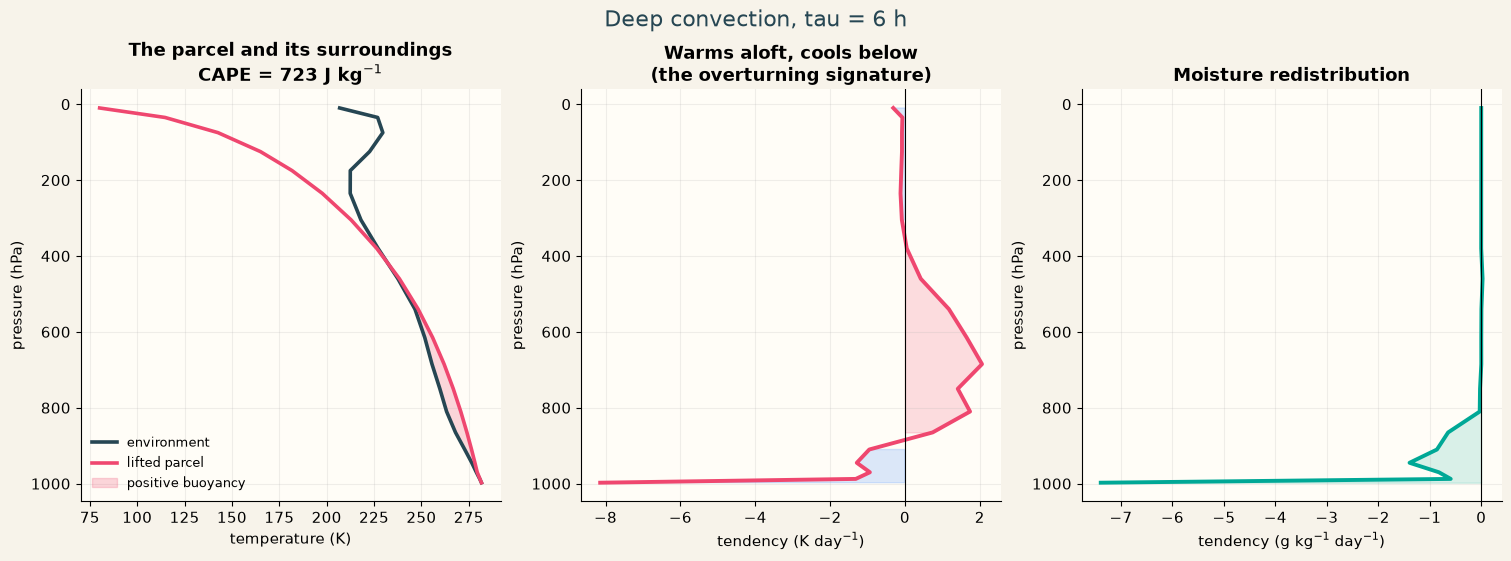

CAPE:                       722.7 J kg-1
cloud base mass flux:      0.0056 kg m-2 s-1
convective rain:            1.747 mm day-1
effective timescale:         6.00 hours
parcel stays buoyant up to 460 hPa

Try: shorten tau_cape to 2 hours. The scheme is being told to consume the
same CAPE three times faster. Watch the mass flux and the rain, and ask
whether a real thunderstorm has a timescale set by the modeller.


In [46]:
#@title What deep convection does { display-mode: "form" }
grid, params, state = column({'tau_cape': float(cape_timescale_hours) * 3600.0})
pressure = pressure_hpa(state)
output = mass_flux_convection(deepcopy(state), grid, params)

# Lift a parcel by hand, one layer at a time, exactly as the scheme does.
# parcel_ascent does the pressure work and the condensation for a single leg.
levels = state['p'].shape[1]
source = levels - 1
parcel_t = np.full(levels, np.nan)
parcel_q = np.full(levels, np.nan)
current_t = state['t'][:, source:source + 1].clone()
current_q = state['q'][:, source:source + 1].clone()
parcel_t[source] = current_t.item()
parcel_q[source] = current_q.item()
for level in range(source - 1, -1, -1):
    current_t, current_q, _ = parcel_ascent(
        current_t, current_q,
        state['p'][:, level + 1:level + 2],
        state['p'][:, level:level + 1],
    )
    parcel_t[level] = current_t.item()
    parcel_q[level] = current_q.item()

environment = profile(state['t'])
environment_q = profile(state['q'])
# buoyancy uses virtual temperature: water vapour is lighter than dry air
parcel_tv = parcel_t * (1 + 0.608 * parcel_q)
environment_tv = environment * (1 + 0.608 * environment_q)
buoyant = parcel_tv > environment_tv

heat = profile(output['dt'], 86400)
moisture = profile(output['dq'], 86400 * 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), constrained_layout=True)

axes[0].plot(environment, pressure, color=colors['storm'], linewidth=2.6,
             label='environment')
axes[0].plot(parcel_t, pressure, color=colors['heat'], linewidth=2.6,
             label='lifted parcel')
axes[0].fill_betweenx(pressure, environment, parcel_t, where=buoyant,
                      color=colors['heat'], alpha=0.22, label='positive buoyancy')
axes[0].set(xlabel='temperature (K)',
            title=f"The parcel and its surroundings\nCAPE = {output['cape'][0].item():.0f} J kg$^{{-1}}$")
axes[0].legend(frameon=False, fontsize=9)
pressure_axis(axes[0])

axes[1].plot(heat, pressure, color=colors['heat'], linewidth=2.8)
axes[1].fill_betweenx(pressure, 0, heat, where=heat >= 0, color=colors['heat'], alpha=0.18)
axes[1].fill_betweenx(pressure, 0, heat, where=heat < 0, color=colors['sky'], alpha=0.18)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set(xlabel='tendency (K day$^{-1}$)',
            title='Warms aloft, cools below\n(the overturning signature)')
pressure_axis(axes[1])

axes[2].plot(moisture, pressure, color=colors['rain'], linewidth=2.8)
axes[2].fill_betweenx(pressure, 0, moisture, color=colors['rain'], alpha=0.15)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set(xlabel='tendency (g kg$^{-1}$ day$^{-1}$)', title='Moisture redistribution')
pressure_axis(axes[2])

fig.suptitle(f'Deep convection, tau = {cape_timescale_hours:.0f} h',
             fontsize=16, color=colors['storm'])
plt.show()

print(f"CAPE:                    {output['cape'][0].item():8.1f} J kg-1")
print(f"cloud base mass flux:    {output['cloud_base_mass_flux'][0].item():8.4f} kg m-2 s-1")
print(f"convective rain:         {output['precip'][0].item() * 86400:8.3f} mm day-1")
print(f"effective timescale:     {output['tau_cape_eff'][0].item() / 3600:8.2f} hours")
print(f"parcel stays buoyant up to {pressure[np.argmax(buoyant)]:.0f} hPa")
print()
print('Try: shorten tau_cape to 2 hours. The scheme is being told to consume the')
print('same CAPE three times faster. Watch the mass flux and the rain, and ask')
print('whether a real thunderstorm has a timescale set by the modeller.')


## 10. Condensation and cloud: what the grid box cannot see

A model layer is a box that can be up to hundreds of kilometres wide. Inside it, humidity is not
uniform - some parts are saturated and cloudy while the box average is well
below saturation. If you condense only when the *average* reaches 100%, you get
no cloud until the whole box saturates, and then the box is pinned at exactly
100% forever.

The fix is to assume a **subgrid distribution**. Treat total water as spread
uniformly about the mean with half width $D = (1 - RH_{\rm crit})q_s$, and condense only
the part of the distribution above saturation. Writing $s = q + D - q_s$:

$$f = \frac{s}{2D}, \qquad q_c = \frac{s^2}{4D}. $$

At $RH_{\rm crit} = 1$ the distribution collapses to a spike and you recover plain
saturation adjustment. Below 1 the box can carry partial cloud at, say, 85%
mean humidity, which is what real air does.

The accepted reference uses $RH_{\rm crit} = 0.90$. Its grid-mean humidity remains
below saturation throughout the column while condensation and rain still occur.
Use the profile below to identify what a coarse 20-level model can represent and
what would require finer resolution or additional cloud physics.

**Turn the knob and record:** Move `rh_critical` from 0.70 up to 1.00 and watch
what happens at the top of the range in particular.

> **What you observed:** At RH_crit = 0.90 the largest cloud fraction is ______ at
> ______ hPa, with grid-mean humidity there of ______ %. At RH_crit = 1.00 the
> cloud fraction becomes ______ and the humidity is pinned at ______ %. Which of
> those two behaves more like real air, and why? ______


In [ ]:
#@title slider for shallow convection relative humidity trigger { display-mode: "form" }
rh_critical = 0.90 #@param {type:"slider", min:0.70, max:1.00, step:0.01}

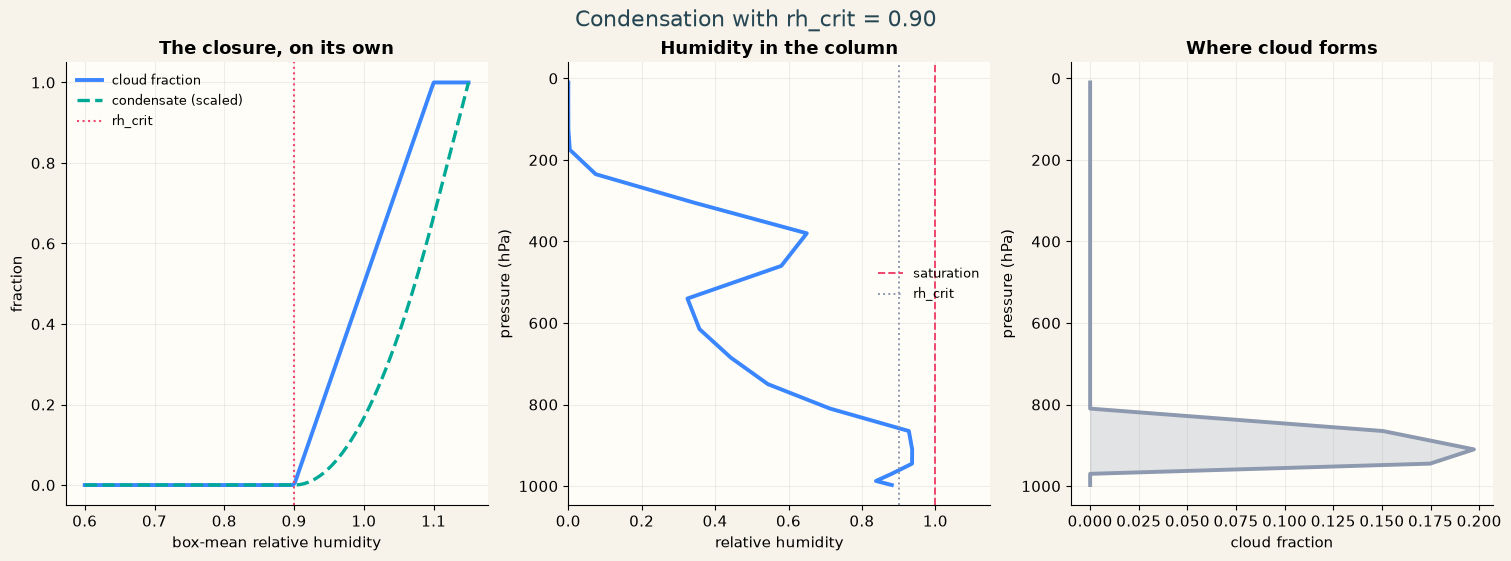

condensed in this one step: 4.531 kg m-2
large-scale rain in a full physics step: 1.517 mm day-1
peak cloud fraction: 0.197
levels at or above 95% RH: 0 of 20

Those two numbers disagree on purpose. Called on its own, condensation
sees supersaturation that the other schemes would already have consumed,
and removes all of it at once. Isolating a parameterization tells you what
the rule does, not what the model does.

Try: slide rh_crit to 1.00. The cloud fraction curve in the left panel
becomes a step, and the column can only be clear or completely saturated.
That was the model default until recently, and it is why the moist band
used to be pinned at exactly 100%.


In [59]:
#@title What condensation does { display-mode: "form" }
grid, params, state = column({'condensation_rh_crit': float(rh_critical)})
pressure = pressure_hpa(state)
output = condensation(deepcopy(state), grid, params)

humidity = profile(relative_humidity(state['q'], state['t'], state['p']))
fraction = profile(output['condensation_cloud_fraction'])

# the closure itself, drawn as a function of box-mean humidity
mean_rh = np.linspace(0.60, 1.15, 200)
half_width = 1.0 - float(rh_critical)
if half_width <= 0:
    closure_fraction = (mean_rh >= 1.0).astype(float)
    closure_condensate = np.maximum(mean_rh - 1.0, 0.0)
else:
    excess = mean_rh + half_width - 1.0
    closure_fraction = np.clip(excess / (2 * half_width), 0.0, 1.0)
    closure_condensate = np.where(
        closure_fraction >= 1.0, mean_rh - 1.0,
        np.maximum(excess, 0.0) ** 2 / (4 * half_width))

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), constrained_layout=True)

axes[0].plot(mean_rh, closure_fraction, color=colors['sky'], linewidth=2.8,
             label='cloud fraction')
axes[0].plot(mean_rh, closure_condensate / max(closure_condensate.max(), 1e-9),
             color=colors['rain'], linewidth=2.4, linestyle='--',
             label='condensate (scaled)')
axes[0].axvline(float(rh_critical), color=colors['heat'], linewidth=1.5,
                linestyle=':', label='rh_crit')
axes[0].set(xlabel='box-mean relative humidity', ylabel='fraction',
            title='The closure, on its own')
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(alpha=0.2)

axes[1].plot(humidity, pressure, color=colors['sky'], linewidth=2.8)
axes[1].axvline(1.0, color=colors['heat'], linestyle='--', linewidth=1.4,
                label='saturation')
axes[1].axvline(float(rh_critical), color=colors['cloud'], linestyle=':',
                linewidth=1.4, label='rh_crit')
axes[1].set(xlabel='relative humidity', xlim=(0, 1.15),
            title='Humidity in the column')
axes[1].legend(frameon=False, fontsize=9, loc='center right')
pressure_axis(axes[1])

axes[2].plot(fraction, pressure, color=colors['cloud'], linewidth=2.8)
axes[2].fill_betweenx(pressure, 0, fraction, color=colors['cloud'], alpha=0.25)
axes[2].set(xlabel='cloud fraction', title='Where cloud forms')
pressure_axis(axes[2])

fig.suptitle(f'Condensation with rh_crit = {rh_critical:.2f}',
             fontsize=16, color=colors['storm'])
plt.show()

_, full_step, _ = physics_step(deepcopy(state), grid, params)
print(f"condensed in this one step: {output['precip'][0].item() * params['dt']:.3f} kg m-2")
print(f"large-scale rain in a full physics step: "
      f"{full_step['precip_ls'][0].item() * 86400:.3f} mm day-1")
print(f"peak cloud fraction: {fraction.max():.3f}")
print(f"levels at or above 95% RH: {(humidity >= 0.95).sum()} of {len(humidity)}")
print()
print('Those two numbers disagree on purpose. Called on its own, condensation')
print('sees supersaturation that the other schemes would already have consumed,')
print('and removes all of it at once. Isolating a parameterization tells you what')
print('the rule does, not what the model does.')
print()
print('Try: slide rh_crit to 1.00. The cloud fraction curve in the left panel')
print('becomes a step, and the column can only be clear or completely saturated.')
print('That was the model default until recently, and it is why the moist band')
print('used to be pinned at exactly 100%.')


## 11. The slab ocean: why the answer takes so long

The surface is a slab of water of fixed depth that stores heat and warms when
the net flux into it is positive. That is the entire ocean model, and it does
one job: it sets **how long the column takes to respond**.

The relaxation time scales with depth. A 50 m slab has an e-folding time of
about 1150 days; a 5 m slab about 115 days, exactly a tenth of it. The reference
atmosphere was therefore equilibrated with a 5 m slab, and given 500 days --
more than four e-folding times, so it really has converged. The interactive
experiments below run on 50 m, the standard mixed-layer depth, because the
slower response is part of the lesson. Both numbers are correct: 5 m built the
starting state, 50 m is what you are experimenting on.

The physical point is worth making: the ocean's heat capacity is why the climate
system responds to a change over decades rather than days, and why the planet is
still warming toward a balance with greenhouse gases already emitted.

**Read the figure and record:** No slider here - the point is a timescale, so
extract it from the curve.

> **What you observed:** The 50 m slab takes about ______ days to close most of the
> gap to equilibrium; the 5 m slab takes about ______ days. The ratio is roughly
> ______, which matches / does not match the ratio of the depths. One consequence
> for the real climate system: ______


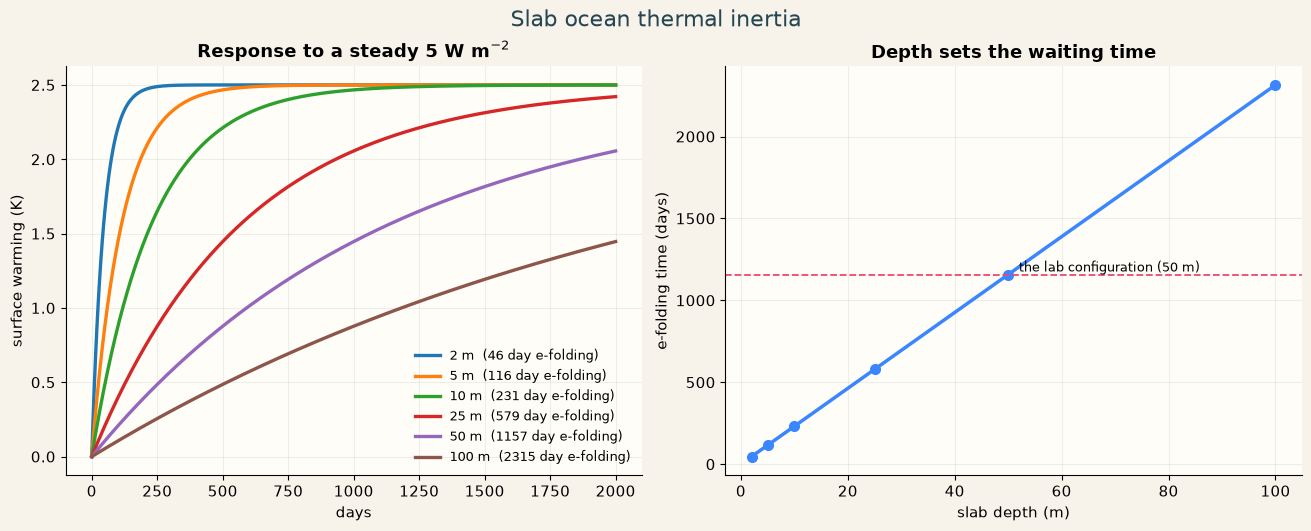

lab configuration: 50 m slab
heat capacity: 2.00e+08 J m-2 K-1

Try: this is an analytic sketch, not the model. Compare it against what
the column actually does in Mission 7 of the second notebook.


In [49]:
#@title How long the surface takes to respond { display-mode: "form" }
rho_water, c_water = 1000.0, 4000.0
depths = np.array([2.0, 5.0, 10.0, 25.0, 50.0, 100.0])
imbalance = 5.0
days_axis = np.linspace(0, 2000, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)

feedback = 2.0  # W m-2 K-1, roughly this column's restoring strength
for depth in depths:
    heat_capacity = rho_water * c_water * depth
    timescale = heat_capacity / feedback / 86400
    response = (imbalance / feedback) * (1 - np.exp(-days_axis / timescale))
    axes[0].plot(days_axis, response, linewidth=2.4,
                 label=f'{depth:.0f} m  ({timescale:.0f} day e-folding)')
axes[0].set(xlabel='days', ylabel='surface warming (K)',
            title=f'Response to a steady {imbalance:.0f} W m$^{{-2}}$')
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(alpha=0.2)

timescales = rho_water * c_water * depths / feedback / 86400
axes[1].plot(depths, timescales, 'o-', color=colors['sky'], linewidth=2.5, markersize=7)
axes[1].axhline(timescales[depths == 50][0], color=colors['heat'],
                linestyle='--', linewidth=1.3)
axes[1].annotate('the lab configuration (50 m)',
                 xy=(52, timescales[depths == 50][0]), fontsize=9,
                 va='bottom')
axes[1].set(xlabel='slab depth (m)', ylabel='e-folding time (days)',
            title='Depth sets the waiting time')
axes[1].grid(alpha=0.2)

fig.suptitle('Slab ocean thermal inertia', fontsize=16, color=colors['storm'])
plt.show()

print(f'lab configuration: {experiment["ocean_depth"]:.0f} m slab')
print(f'heat capacity: {rho_water * c_water * experiment["ocean_depth"]:.2e} J m-2 K-1')
print()
print('Try: this is an analytic sketch, not the model. Compare it against what')
print('the column actually does in Mission 7 of the second notebook.')


## 12. All of it at once

Every scheme you have met is called in sequence, once per fifteen-minute step.
This is the whole column in one figure: which process changes the temperature and
moisture of which layer, and by how much.

Read it as a competition. Radiation cools nearly everywhere, and everything else
is arranged to put that energy back. In a column at equilibrium the columns of
this map sum to nearly zero at every level - not because any one scheme is
balanced, but because together they are.

That is the point at which you should move to [`02_experiments.ipynb`](https://colab.research.google.com/github/evanwellmeyer/GCM/blob/main/notebooks/02_experiments.ipynb),
where the column is allowed to run forward and you can push it and watch it
recover.

**Read the figure and record:** This is the summary figure, so use it to check
whether the story of the whole notebook holds together.

> **What you observed:** Radiation cools the troposphere at about ______ K/day. The
> processes that put that energy back, and the layers where each one dominates:
> ______ Summing every process at 500 hPa gives about ______ K/day, and at 900 hPa
> about ______ K/day. Which single scheme would you most want to improve, and what
> would you look at first? ______


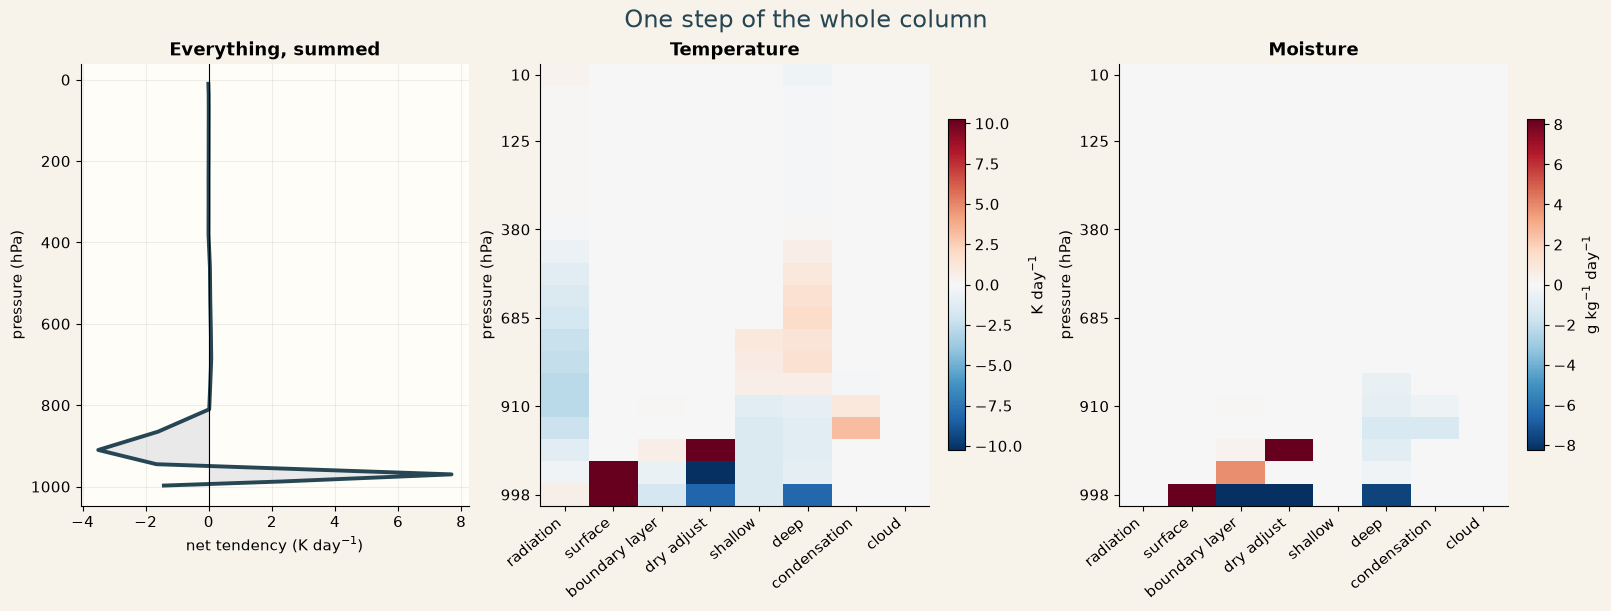

instantaneous TOA net flux:   +0.927 W m-2
instantaneous surface flux:  +1.324 W m-2
50-day mean TOA net flux:     +0.934 W m-2
50-day mean surface flux:     +0.409 W m-2
column energy residual:      -0.1606 W m-2
largest net tendency:          7.693 K day-1   (at 970 hPa)

The largest net tendency sits in the boundary layer, where surface
heating and turbulent mixing are two large numbers that nearly cancel.
Instantaneous fluxes fluctuate; equilibrium is assessed from 50-day means.

The residual is the accounting check: energy the model cannot place.
Against the ~240 W m-2 flowing through the column it is a fraction of a
percent, which is what you want. Now go and break the column in the
second notebook.


In [50]:
#@title Every scheme at once { display-mode: "form" }
grid, params, state = column()
pressure = pressure_hpa(state)
# Let the column take six hours first. A saved state is restarted with its slab
# heat content zeroed and part-way through the radiation sub-cycle, so the very
# first step carries a restart transient that is not the model's climate.
settled = deepcopy(state)
for _ in range(24):
    settled, diagnostics, _ = physics_step(settled, grid, params)

processes = [
    ('radiation', 'radiation'), ('surface', 'surface'),
    ('boundary layer', 'boundary_layer'), ('dry adjust', 'dry_adjustment'),
    ('shallow', 'shallow'), ('deep', 'deep'),
    ('condensation', 'condensation'), ('cloud', 'cloud'),
]
names = [label for label, _ in processes]
temperature_map = np.array([
    profile(diagnostics[f'{key}_temperature_tendency'], 86400) for _, key in processes])
moisture_map = np.array([
    profile(diagnostics[f'{key}_moisture_tendency'], 86400 * 1000) for _, key in processes])

fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

total = temperature_map.sum(axis=0)
axes[0].plot(total, pressure, color=colors['storm'], linewidth=2.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].fill_betweenx(pressure, 0, total, color=colors['cloud'], alpha=0.20)
axes[0].set(xlabel='net tendency (K day$^{-1}$)', title='Everything, summed')
pressure_axis(axes[0])

ticks = np.linspace(0, len(pressure) - 1, 6).astype(int)
for ax, values, title, label in [
    (axes[1], temperature_map, 'Temperature', 'K day$^{-1}$'),
    (axes[2], moisture_map, 'Moisture', 'g kg$^{-1}$ day$^{-1}$'),
]:
    limit = max(np.nanpercentile(np.abs(values), 98), 1e-6)
    image = ax.imshow(values.T, origin='upper', aspect='auto', cmap='RdBu_r',
                      vmin=-limit, vmax=limit)
    ax.set_xticks(range(len(names)), names, rotation=40, ha='right')
    ax.set_yticks(ticks, [f'{pressure[i]:.0f}' for i in ticks])
    ax.set(title=title, ylabel='pressure (hPa)')
    fig.colorbar(image, ax=ax, shrink=0.75, label=label)

fig.suptitle('One step of the whole column', fontsize=17, color=colors['storm'])
plt.show()

print(f"instantaneous TOA net flux:  {diagnostics['toa_net'][0].item():+7.3f} W m-2")
print(f"instantaneous surface flux: {diagnostics['surface_total_flux'][0].item():+7.3f} W m-2")
print(f"50-day mean TOA net flux:    {metadata['toa_net_wm2']:+7.3f} W m-2")
print(f"50-day mean surface flux:    {metadata['surface_total_flux_wm2']:+7.3f} W m-2")
print(f"column energy residual:      {diagnostics['column_energy_residual'][0].item():+7.4f} W m-2")
print(f"largest net tendency:        {np.abs(total).max():7.3f} K day-1"
      f"   (at {pressure[np.abs(total).argmax()]:.0f} hPa)")
print()
print('The largest net tendency sits in the boundary layer, where surface')
print('heating and turbulent mixing are two large numbers that nearly cancel.')
print('Instantaneous fluxes fluctuate; equilibrium is assessed from 50-day means.')
print()
print('The residual is the accounting check: energy the model cannot place.')
print('Against the ~240 W m-2 flowing through the column it is a fraction of a')
print('percent, which is what you want. Now go and break the column in the')
print('second notebook.')
